In [3]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplot.ex_01 import explode

In [4]:
titanic = sns.load_dataset("titanic")

In [5]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [7]:
titanic.to_csv(path_or_buf="titanic.csv", index=False)

In [8]:
print(titanic.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [9]:
titanic['age'] = titanic['age'].fillna(value = titanic['age'].median())

In [10]:
titanic['age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: age, Length: 891, dtype: float64

In [11]:
print(titanic['age'].isnull().sum())

0


In [12]:
titanic['embarked'].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [17]:
titanic['embarked'] = titanic['embarked'].fillna(value = 'S')

In [19]:
print(titanic['embarked'].isnull().sum())

0


In [20]:
titanic['deck'].value_counts()

deck
C    59
B    47
D    33
E    32
A    15
F    13
G     4
Name: count, dtype: int64

In [21]:
titanic['deck'] = titanic['deck'].fillna(value = 'C')

In [22]:
titanic['deck']

0      C
1      C
2      C
3      C
4      C
      ..
886    C
887    B
888    C
889    C
890    C
Name: deck, Length: 891, dtype: category
Categories (7, str): ['A', 'B', 'C', 'D', 'E', 'F', 'G']

In [23]:
titanic['deck'].isnull().sum()

np.int64(0)

In [25]:
titanic['embark_town'].isnull().sum()

np.int64(2)

In [26]:
titanic['embark_town'].value_counts()

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [27]:
titanic['embark_town'] = titanic['embark_town'].fillna(value = 'Cherbourg')

In [28]:
titanic['embark_town'].isnull().sum()

np.int64(0)

In [29]:
titanic['embark_town'].value_counts()

embark_town
Southampton    644
Cherbourg      170
Queenstown      77
Name: count, dtype: int64

In [31]:
titanic[titanic['sex'] == 'male']

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,C,Southampton,no,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,C,Southampton,no,True
5,0,3,male,28.0,0,0,8.4583,Q,Third,man,True,C,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,C,Southampton,no,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
883,0,2,male,28.0,0,0,10.5000,S,Second,man,True,C,Southampton,no,True
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,C,Southampton,no,True
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,C,Southampton,no,True
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [35]:
titanic['survived'][titanic['sex'] == 'male'].value_counts()

survived
0    468
1    109
Name: count, dtype: int64

In [49]:
titanic[titanic['sex'] == 'female']['survived'].value_counts(ascending = True)

survived
0     81
1    233
Name: count, dtype: int64

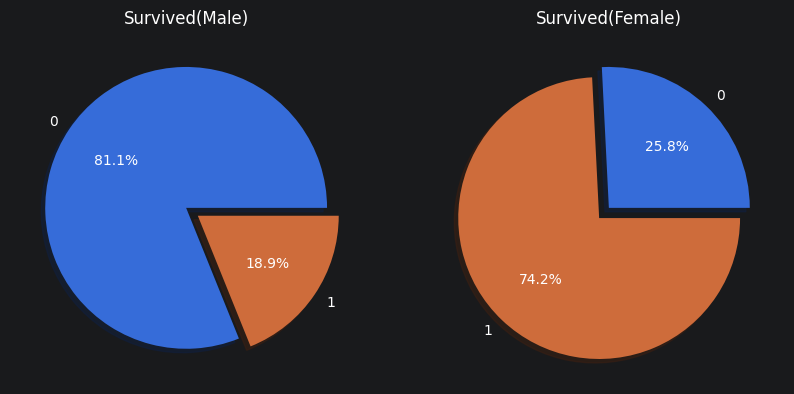

In [51]:
(_, ax) = plt.subplots(nrows = 1, ncols = 2, figsize = (10,5))
titanic['survived'][titanic['sex'] == 'male'].value_counts().plot.pie(explode = [0, 0.1], autopct = '%1.1f%%', ax = ax[0], shadow = True)

titanic['survived'][titanic['sex'] == 'female'].value_counts(ascending=True).plot.pie(explode = [0,0.1], autopct = '%1.1f%%', ax = ax[1], shadow = True)

ax[0].set_title('Survived(Male)')
ax[1].set_title('Survived(Female)')

plt.show()

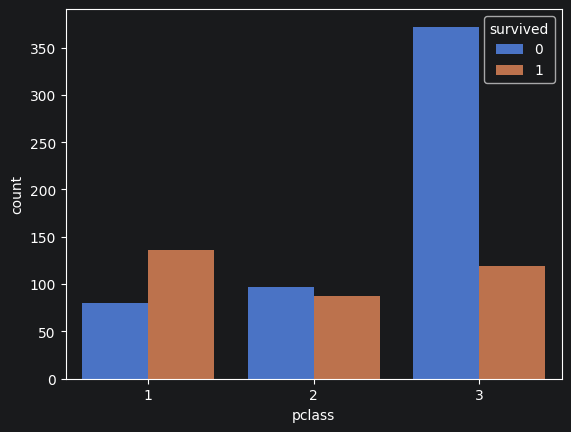

In [52]:
sns.countplot(x = 'pclass', hue = 'survived', data = titanic)
plt.show()

In [55]:
titanic_correlation_analysis = titanic.corr(method = 'pearson')

ValueError: could not convert string to float: 'male'

In [56]:
titanic['survived'].corr(other=titanic['adult_male'], method = 'pearson')

np.float64(-0.5570800422053258)

In [57]:
titanic['survived'].corr(other=titanic['fare'], method = 'pearson')

np.float64(0.2573065223849622)

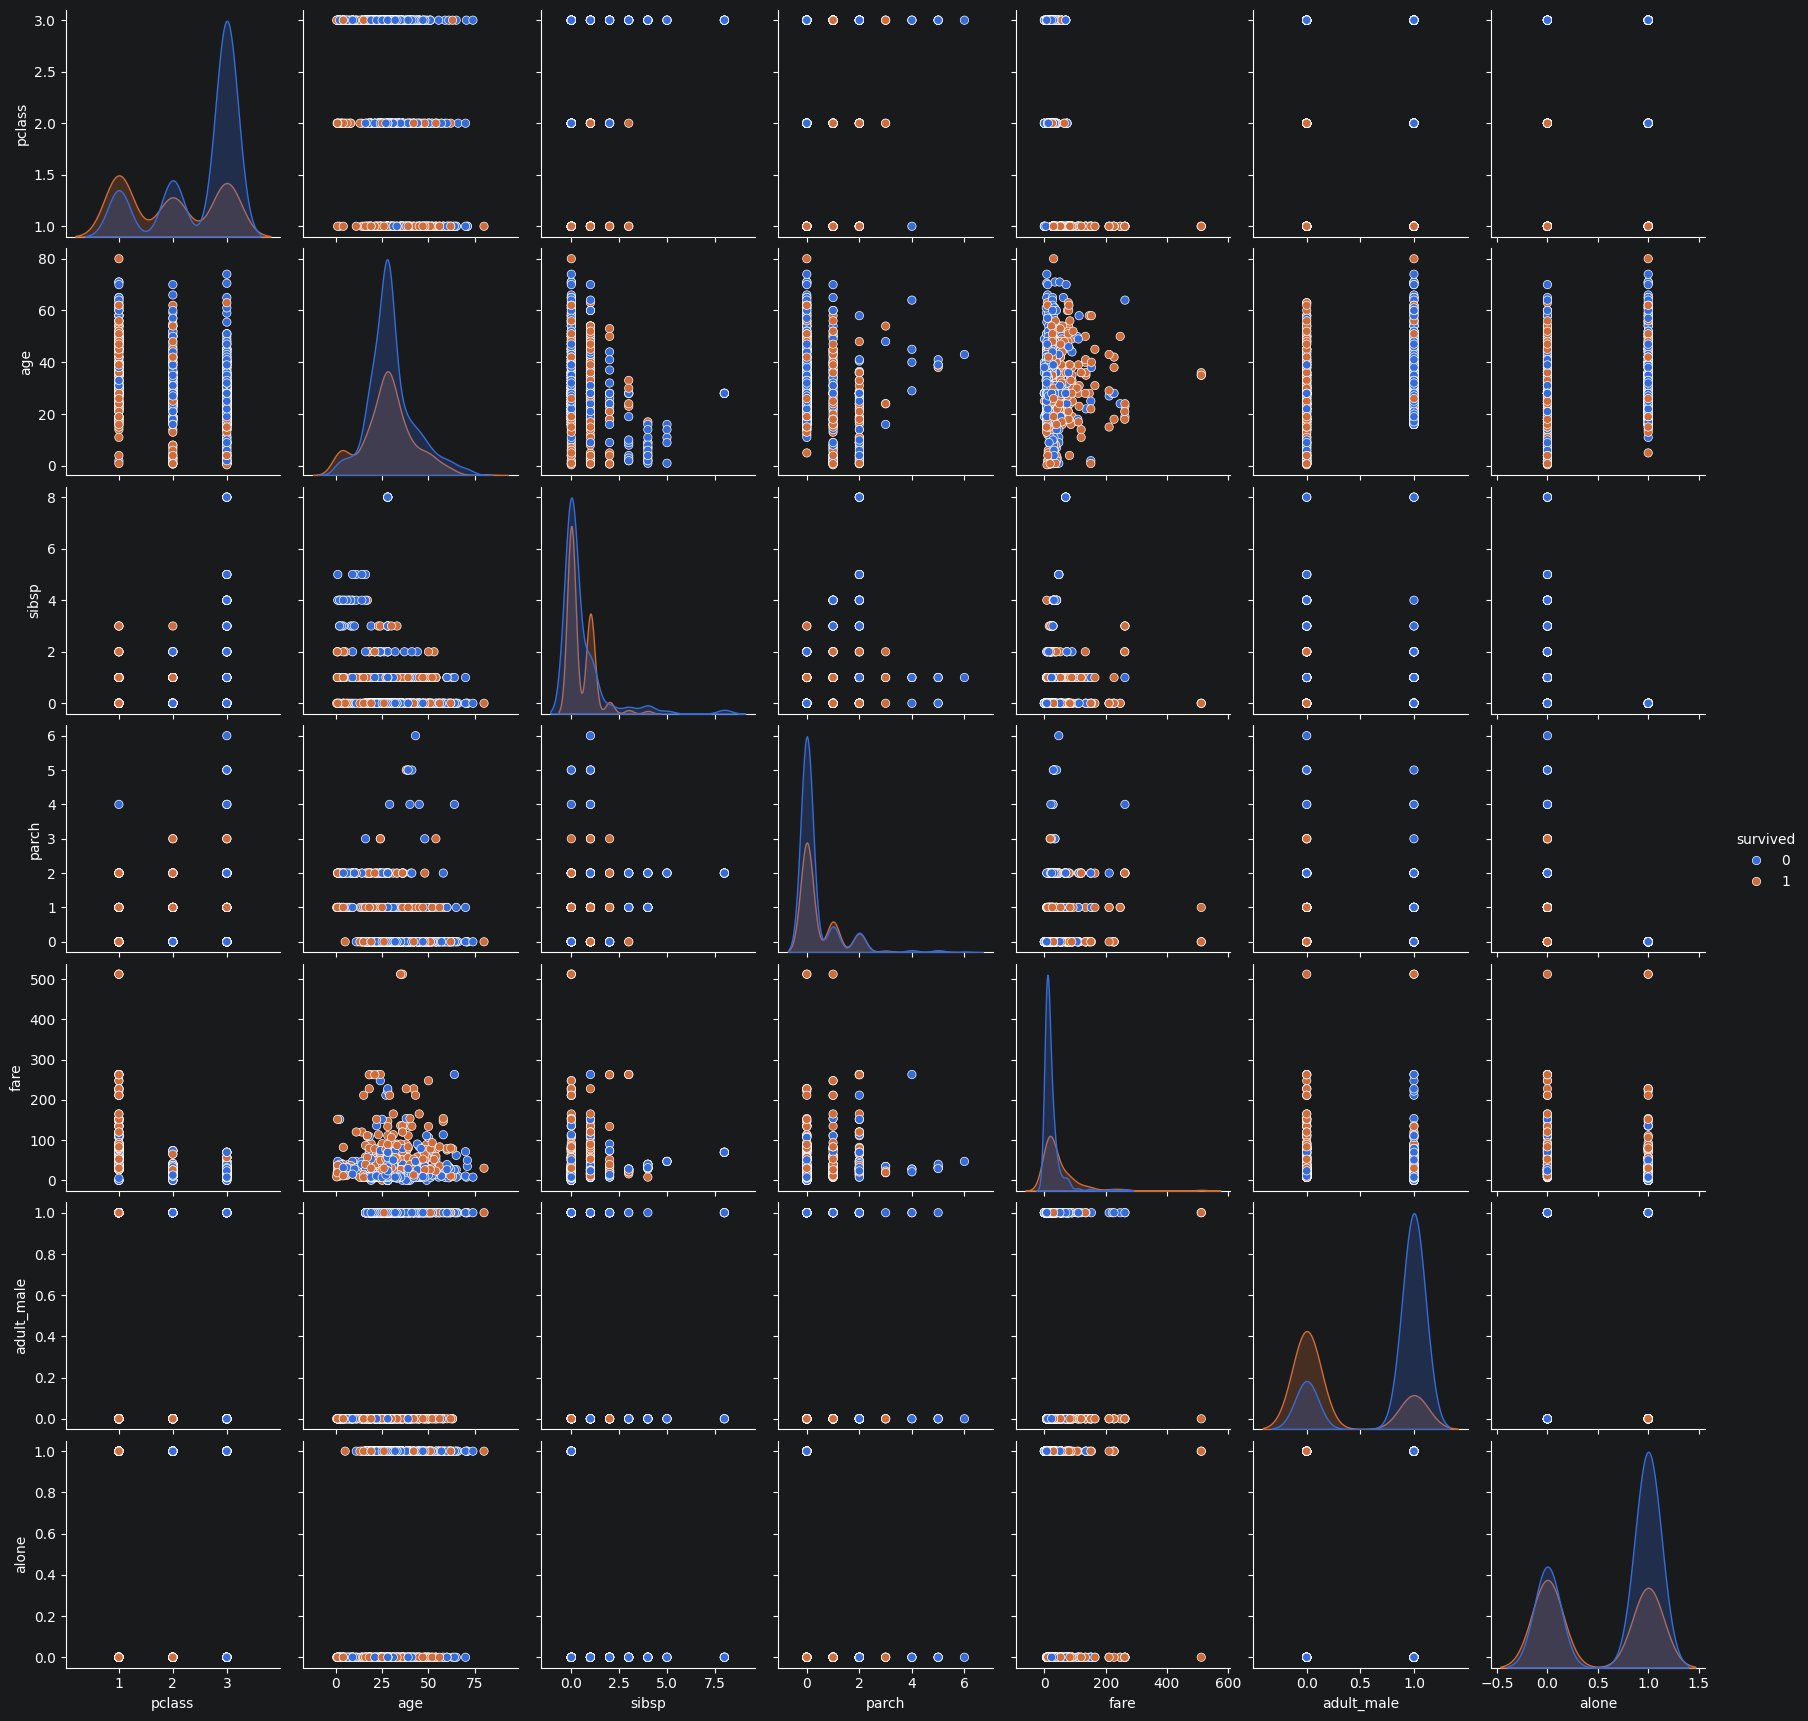

In [58]:
sns.pairplot(data=titanic, hue = 'survived')
plt.show()